# ResNet Custom Model for Drone Acoustic Detection

In [1]:
! pip install torchmetrics pandas datasets numpy torchmetrics scikit-learn seaborn torchcodec torchaudio librosa ipywidgets torchvision wandb


  Using cached torchmetrics-1.9.0-py3-none-any.whl.metadata (23 kB)
  Using cached datasets-4.8.4-py3-none-any.whl.metadata (19 kB)
  Using cached scikit_learn-1.8.0-cp313-cp313-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached torchcodec-0.11.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached torchaudio-2.11.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (6.9 kB)
  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Using cached ipywidgets-8.1.8-py3-none-any.whl.metadata (2.4 kB)
  Using cached torchvision-0.26.0-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (5.5 kB)
  Using cached wandb-0.25.1-py3-none-manylinux_2_28_x86_64.whl.metadata (11 kB)
  Using cached lightning_utilities-0.15.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached pyarrow-23.0.1-cp313-cp313-manylinux_2_28_x86_64.whl.metadata (3.1 kB)
  Using cached dill-0.4.1-py3-none-any.whl.metadat

In [1]:
from datasets import load_from_disk, load_dataset, concatenate_datasets, DatasetDict
from IPython.lib.display import Audio as AudioDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, confusion_matrix, classification_report
from torch.utils.data import DataLoader
from torch import nn, optim
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

import torchmetrics
import librosa
import random
import torch
import os


## Configurations

In [2]:
SEED = 42
BATCH_SIZE = 256 # 512
NUM_WORKERS = 24
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.50E-01 # 1.
MODEL_SAVE_PATH = "models/resnet_custom.pt"
EPOCHS=10
CLASS_NAMES = ["other", "drone"]


# Set seeds for reproducibility between runs
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # Help reproducibility
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

print(f"Using device: {DEVICE}")
print(f"Number of workers: {NUM_WORKERS}")


Using device: cuda
Number of workers: 24


## Dataset & Collate function

In [3]:
# dataset = load_from_disk("datasets/tmp_melspectogram_ds/")
# dataset = load_from_disk("../../dataset/ds_1_melspecto_aug_0-5_balanced_chunked.hf")
# dataset = load_dataset("Hibou-Foundation/ds_121_melspecto_noaug_balanced_chunked")
dataset = load_from_disk("../../../../local/ds_1_MAT-AllTEST_melspectogram")
dataset = dataset.with_format("torch", columns=["audio", "label"])
# Take only n% of the dataset
n_instance = 1
dataset["train"] = dataset["train"].shuffle(seed=42).select(range(int(n_instance * len(dataset["train"]))))
dataset["val"] = dataset["val"].shuffle(seed=42).select(range(int(n_instance * len(dataset["val"]))))
print("\nDataset splits:")
print({k: v.shape for k, v in dataset.items()})
# Drop column "raw_audio"
# dataset = dataset.remove_columns("raw_audio")
print("\nDataset features:")
print(dataset["train"].features)


Loading dataset from disk:   0%|          | 0/43 [00:00<?, ?it/s]


Dataset splits:
{'train': (636820, 2), 'val': (158828, 2)}

Dataset features:
{'audio': List(List(List(Value('float64')))), 'label': ClassLabel(names=['other', 'drone'])}


In [4]:
def collate_fn(batch):
    """
    Prepares a batch for the model.
    """
    xs = []
    for audio in batch:
        xs.append(audio["audio"])

    ys = [b["label"] for b in batch]

    # Stack spectrograms into a batch
    # (B, H, W) -> (B, 1, H, W)
    xs = torch.stack(xs, dim=0)

    # Convert labels to float and add a dimension for BCEWithLogitsLoss
    # (B,) -> (B, 1)
    ys = torch.tensor(ys, dtype=torch.float32).unsqueeze(1)

    return xs, ys


train_loader = DataLoader(dataset["train"], batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)
valid_loader = DataLoader(dataset["val"], batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, collate_fn=collate_fn, pin_memory=True)

print(f"\nCreated DataLoaders with Batch Size: {BATCH_SIZE}")

# Check a sample batch
try:
    sample_x, sample_y = next(iter(train_loader))
    print(f"Sample batch shape - X: {sample_x.shape}, Y: {sample_y.shape}")
except Exception as e:
    print(f"Could not load a sample batch: {e}")



Created DataLoaders with Batch Size: 256
Sample batch shape - X: torch.Size([256, 1, 128, 32]), Y: torch.Size([256, 1])


In [5]:
ds_all_tests = load_dataset("Hibou-Foundation/all_tests_ds_3")


In [6]:
def convert_to_mel_spectrogram(data):
    mel = librosa.feature.melspectrogram(
        y=data,
        sr=16000,
        n_fft=1025,
        hop_length=256,
        n_mels=128,
        fmin=20,
        fmax=8000,
        power=2.0
    )
     # Convert to log scale (dB)
    mel_db = librosa.power_to_db(mel, ref=np.max)
    # Normalize
    mel_db = (mel_db - mel_db.mean()) / (mel_db.std() + 1e-6)
    # Convert to torch tensor: [1, n_mels, time]
    mel_db = torch.tensor(mel_db).unsqueeze(0)

    return mel_db


def collate_fn_librosa_test(batch):
    inputs = []
    labels = []

    for item in batch:
        waveforme = item["audio"]["array"]
        wave = convert_to_mel_spectrogram(waveforme)
        inputs.append(wave)
        labels.append(item["label"])

    # Pad time dimension so all samples in batch have same T
    inputs = torch.nn.utils.rnn.pad_sequence(
        inputs, batch_first=True
    )

    labels = torch.tensor(labels, dtype=torch.float32)

    return inputs, labels


In [7]:
dataloaders = {}
for split in ds_all_tests.keys():
    ds = ds_all_tests[split]
    dataloaders[split] = DataLoader(
        ds,
        batch_size=1,
        shuffle=False,
        num_workers=1,
        collate_fn=collate_fn_librosa_test,
    )
dataloaders


{'drone_test': <torch.utils.data.dataloader.DataLoader at 0x7f64a65b4a50>,
 'drone_test_2': <torch.utils.data.dataloader.DataLoader at 0x7f64bc34c050>,
 'parabole1': <torch.utils.data.dataloader.DataLoader at 0x7f64bc34c2b0>,
 'parabole2': <torch.utils.data.dataloader.DataLoader at 0x7f64a68a32f0>,
 'parabole3': <torch.utils.data.dataloader.DataLoader at 0x7f632c76ef10>,
 'parabole4': <torch.utils.data.dataloader.DataLoader at 0x7f632c76f130>,
 'parabole5': <torch.utils.data.dataloader.DataLoader at 0x7f64bc32c250>,
 'parabole6': <torch.utils.data.dataloader.DataLoader at 0x7f64bc32c550>,
 'parabole7': <torch.utils.data.dataloader.DataLoader at 0x7f64bc32c950>}

## Model Definition

In [8]:
def norm(c):
    return nn.GroupNorm(num_groups=8, num_channels=c)

class SE(nn.Module):
    def __init__(self, c, r=8):
        super().__init__()
        self.fc = nn.Sequential(
            nn.AdaptiveAvgPool2d(2),
            nn.Conv2d(c, c // r, kernel_size=2),
            nn.ReLU(inplace=True),
            nn.Conv2d(c // r, c, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.fc(x)

class ResidualBlock(nn.Module):
    def __init__(self, in_c, out_c, stride=(1, 1)):
        super().__init__()

        self.conv1 = nn.Conv2d(
            in_c, out_c, kernel_size=(5, 3),
            stride=stride, padding=(2, 1), bias=False
        )
        self.bn1 = norm(out_c)
        self.act = nn.ReLU(inplace=True)

        self.conv2 = nn.Conv2d(
            out_c, out_c, kernel_size=(3, 3),
            stride=1, padding=1, bias=False
        )
        self.bn2 = norm(out_c)

        self.se = SE(out_c)

        self.shortcut = nn.Identity()
        if stride != (1, 1) or in_c != out_c:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=1, stride=stride, bias=False),
                norm(out_c)
            )

    def forward(self, x):
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out = out + self.shortcut(x)
        return self.act(out)

class AudioResNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Stem: preserve time, reduce frequency
        self.conv1 = nn.Conv2d(
            1, 32, kernel_size=(5, 3),
            stride=(1, 2), padding=(2, 1), bias=False
        )
        self.bn1 = norm(32)
        self.act = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(
            kernel_size=(1, 3), stride=(1, 1), padding=(0, 1)
        )

        # Residual stages (6 blocks total)
        self.layer1 = self._make_layer(32, 64, blocks=2, stride=(1, 2))
        self.layer2 = self._make_layer(64, 128, blocks=2, stride=(1, 1))
        self.layer3 = self._make_layer(128, 256, blocks=2, stride=(2, 2))

        self.dropout = nn.Dropout(0.2)

        # Pool frequency only
        self.freq_pool = nn.AdaptiveAvgPool2d((None, 1))

        # Temporal aggregation
        self.temporal = nn.Sequential(
            nn.Conv1d(256, 128, kernel_size=3, padding=1, bias=False),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool1d(1)
        )

        # Classifier
        self.fc = nn.Linear(128, 1)

    def _make_layer(self, in_c, out_c, blocks, stride):
        layers = [ResidualBlock(in_c, out_c, stride)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_c, out_c, stride=(1, 1)))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.act(self.bn1(self.conv1(x)))
        x = self.pool1(x)

        x = self.layer1(x)
        x = self.dropout(x)
        x = self.layer2(x)
        x = self.dropout(x)
        x = self.layer3(x)
        #x = self.dropout(x)

        # (B, C, T, F) -> pool F only
        x = self.freq_pool(x)
        x = x.squeeze(-1)     # (B, C, T)

        x = self.temporal(x)  # (B, 128, 1)
        x = x.squeeze(-1)

        return self.fc(x)


## Training Setup

In [9]:
model = AudioResNet().to(DEVICE)


In [10]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

metric_acc = torchmetrics.classification.BinaryAccuracy().to(DEVICE)


In [25]:
best_val_acc = 0.0
history = {
    "train_loss": [], "val_loss": [],
    "train_acc": [], "val_acc": []
}

print("\nStarting training...")

for epoch in range(EPOCHS):
    model.train()
    running_train_loss = 0.0
    metric_acc.reset()

    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Train]", unit="batch")

    for x, y in train_pbar:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        out = model(x)
        loss = criterion(out, y)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Metrics
        running_train_loss += loss.item() * x.size(0)
        metric_acc.update(out, y)

        train_pbar.set_postfix(loss=loss.item())

    scheduler.step()

    epoch_train_loss = running_train_loss / len(train_loader.dataset)
    epoch_train_acc = metric_acc.compute().item()

    history["train_loss"].append(epoch_train_loss)
    history["train_acc"].append(epoch_train_acc)

    model.eval()
    running_val_loss = 0.0
    metric_acc.reset()

    valid_pbar = tqdm(valid_loader, desc=f"Epoch {epoch+1}/{EPOCHS} [Valid]", unit="batch")

    with torch.no_grad():
        for x, y in valid_pbar:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            out = model(x)
            loss = criterion(out, y)

            running_val_loss += loss.item() * x.size(0)
            metric_acc.update(out, y)

            valid_pbar.set_postfix(loss=loss.item())

    epoch_val_loss = running_val_loss / len(valid_loader.dataset)
    epoch_val_acc = metric_acc.compute().item()

    history["val_loss"].append(epoch_val_loss)
    history["val_acc"].append(epoch_val_acc)

    print(f"\nEpoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | "
          f"Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | "
          f"Val Acc: {epoch_val_acc:.4f}")


    with open("training_history.txt", "a") as f:
        f.write(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {epoch_train_loss:.4f} | "
                f"Train Acc: {epoch_train_acc:.4f} | Val Loss: {epoch_val_loss:.4f} | "
                f"Val Acc: {epoch_val_acc:.4f}\n")
    # Save the best model
    if epoch_val_acc > best_val_acc:
        best_val_acc = epoch_val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"Saved new best model to {MODEL_SAVE_PATH} (Val Acc: {best_val_acc:.4f})")

        with open("training_history.txt", "a") as f:
            f.write(f"Saved new best model to {MODEL_SAVE_PATH} (Val Acc: {best_val_acc:.4f})\n")



print("\nTraining complete.")




Starting training...


Epoch 1/10 [Valid]: 100%|██████████| 621/621 [01:14<00:00,  8.39batch/s, loss=0.0424]



Epoch 1/10 | Train Loss: 0.1156 | Train Acc: 0.9576 | Val Loss: 0.0813 | Val Acc: 0.9718
Saved new best model to models/resnet_custom.pt (Val Acc: 0.9718)


Epoch 2/10 [Train]:   0%|          | 6/2488 [00:07<53:46,  1.30s/batch, loss=0.0625]  


KeyboardInterrupt: 

## Training Visualization

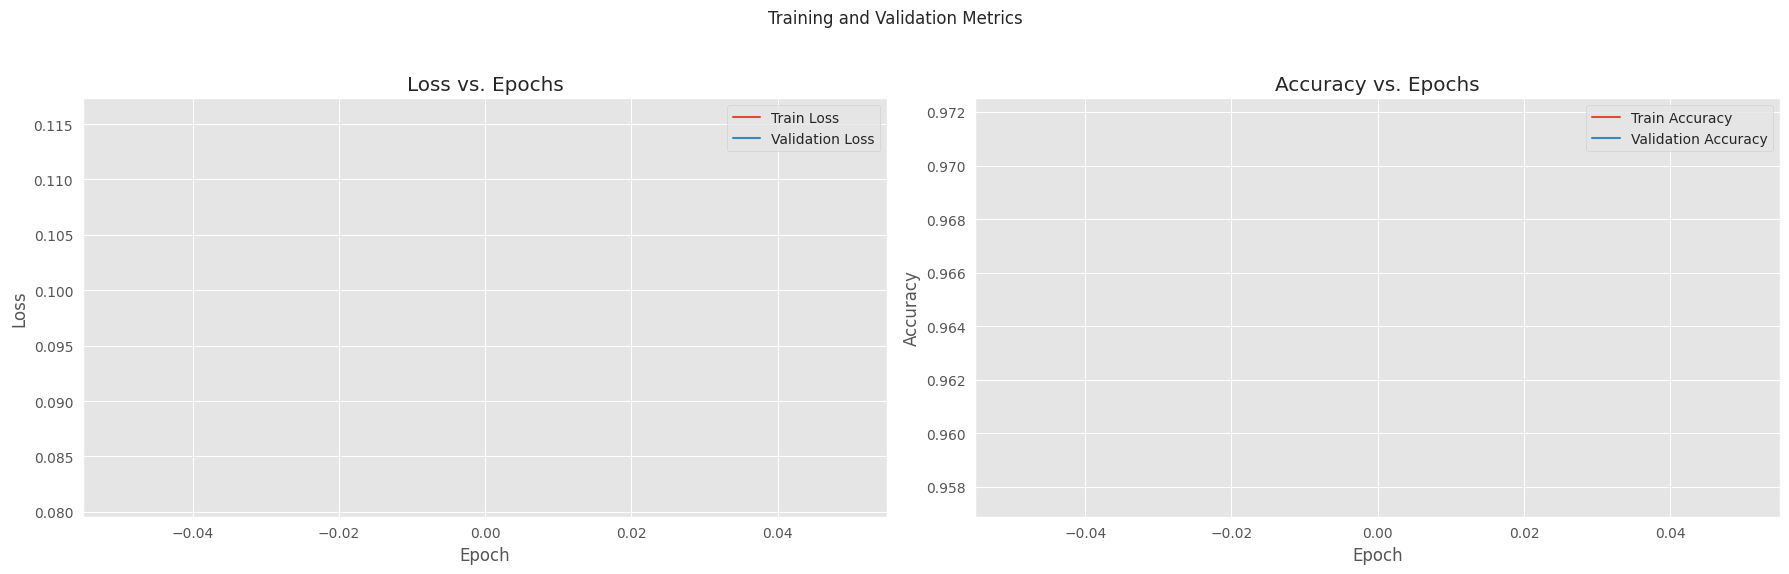

In [26]:


if history["train_loss"]:
    plt.style.use("ggplot")
    fig, (ax1, ax2) = plt.subplots(1, 2
                                   , figsize=(18, 6))

    # Plot Loss
    ax1.plot(history["train_loss"], label="Train Loss")
    ax1.plot(history["val_loss"], label="Validation Loss")
    ax1.set_title("Loss vs. Epochs")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.legend()

    # Plot Accuracy
    ax2.plot(history["train_acc"], label="Train Accuracy")
    ax2.plot(history["val_acc"], label="Validation Accuracy")
    ax2.set_title("Accuracy vs. Epochs")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Accuracy")
    ax2.legend()

    plt.suptitle("Training and Validation Metrics")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


### Model loading and Test Evaluation

Change LOAD_MODEL_PATH to load a different model if needed

In [11]:
LOAD_MODEL_PATH = MODEL_SAVE_PATH
print(f"Loading best model from {LOAD_MODEL_PATH}...")
model = model.to(DEVICE)
model.load_state_dict(torch.load(LOAD_MODEL_PATH, map_location=DEVICE))
model.eval()
print("Loaded best model and set to eval mode.")


Loading best model from models/resnet_custom.pt...
Loaded best model and set to eval mode.


In [12]:
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for x, y in tqdm(valid_loader, desc="Testing"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        logits = model(x)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        all_preds.extend(preds.cpu().numpy().flatten())
        all_probs.extend(probs.cpu().numpy().flatten())
        all_labels.extend(y.cpu().numpy().flatten())

print("\nTest evaluation complete.")


Testing: 100%|██████████| 621/621 [01:15<00:00,  8.27it/s]


Test evaluation complete.


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



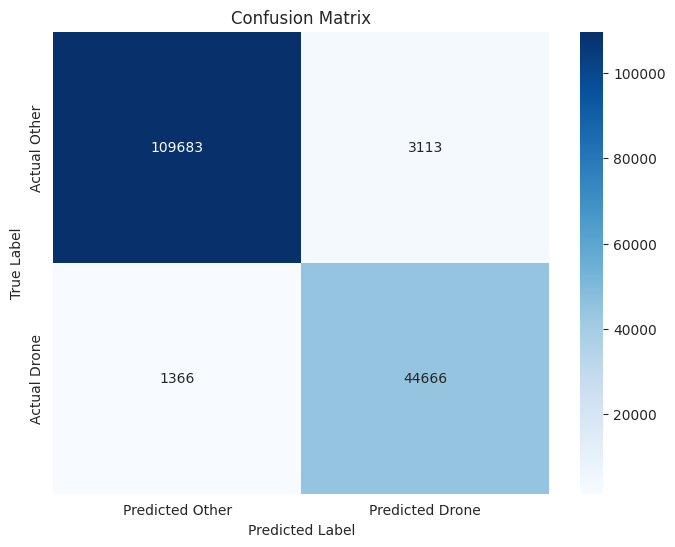


Results DataFrame head:
   true_label  pred_label  confidence
0         0.0         0.0    0.000980
1         0.0         1.0    0.506980
2         0.0         0.0    0.017737
3         0.0         0.0    0.015451
4         0.0         0.0    0.006259


In [13]:
accuracy = accuracy_score(all_labels, all_preds)
print(f"\nTest Accuracy: {accuracy*100:.2f}%")
# target_names = dataset["train"].features["label"].names
target_names = ["Other", "Drone"]

print("\nClassification Report:")
print(all_preds, all_labels)
print(classification_report(all_labels, all_preds, target_names=target_names, digits=3))
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f"Predicted {target_names[0]}", f"Predicted {target_names[1]}"],
            yticklabels=[f"Actual {target_names[0]}", f"Actual {target_names[1]}"])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

df_results = pd.DataFrame({
    "true_label": all_labels,
    "pred_label": all_preds,
    "confidence": all_probs
})

print("\nResults DataFrame head:")
print(df_results.head())


## Evaluation on Custom Test Sets

In [14]:
results = {}
for split, loader in dataloaders.items():
    y_true, y_pred = [], []
    for x, y in tqdm(loader, desc=f"Testing {split}"):
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits = model(x).squeeze(1)
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()

        y_pred.extend(preds.cpu().numpy().flatten())
        y_true.extend(y.cpu().numpy().flatten())
    results[split] = (y_true, y_pred)


Testing parabole7: 100%|██████████| 7953/7953 [00:23<00:00, 335.46it/s]


In [15]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true).astype(int)
    y_pred = np.array(y_pred).astype(int)

    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    try:
        auc = roc_auc_score(y_true, y_pred)
    except:
        auc = float("nan")

    return {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "auc": auc,
        "confusion_matrix": cm,
    }

metrics = {}
for split, (y_true, y_pred) in results.items():
    metrics[split] = compute_metrics(y_true, y_pred)
    print(split, metrics[split])


drone_test {'accuracy': 0.8006718924972005, 'precision': 0.9951923076923077, 'recall': 0.5390625, 'f1': 0.6993243243243243, 'auc': 0.7685489317288802, 'confusion_matrix': array([[508,   1],
       [177, 207]])}
drone_test_2 {'accuracy': 0.9265597147950089, 'precision': 1.0, 'recall': 0.9265335235378032, 'f1': 0.9618659755646057, 'auc': 0.9632667617689016, 'confusion_matrix': array([[   1,    0],
       [ 206, 2598]])}
parabole1 {'accuracy': 0.7804878048780488, 'precision': 0.7475728155339806, 'recall': 0.9871794871794872, 'f1': 0.850828729281768, 'auc': 0.7047008547008548, 'confusion_matrix': array([[19, 26],
       [ 1, 77]])}
parabole2 {'accuracy': 0.7764705882352941, 'precision': 0.7564102564102564, 'recall': 1.0, 'f1': 0.8613138686131386, 'auc': 0.6346153846153846, 'confusion_matrix': array([[ 7, 19],
       [ 0, 59]])}
parabole3 {'accuracy': 0.9490909090909091, 'precision': 1.0, 'recall': 0.9377777777777778, 'f1': 0.9678899082568807, 'auc': 0.9688888888888889, 'confusion_matrix': 

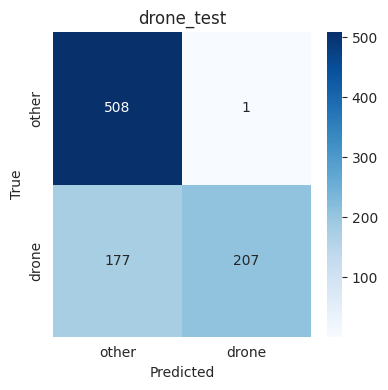

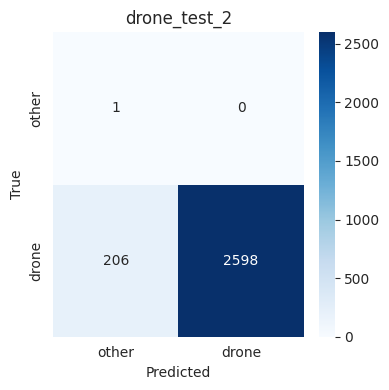

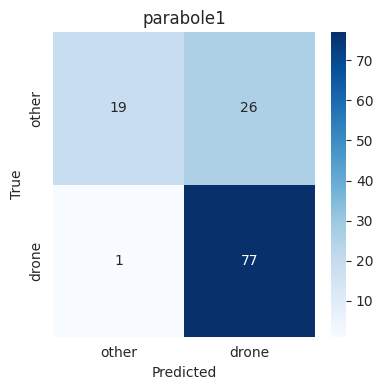

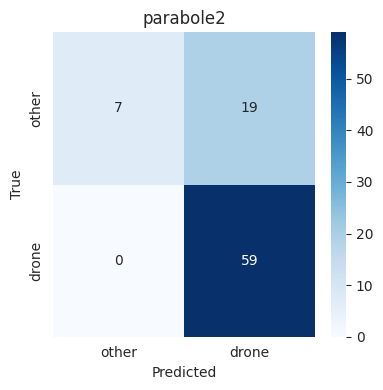

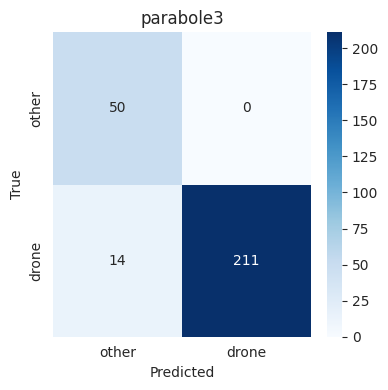

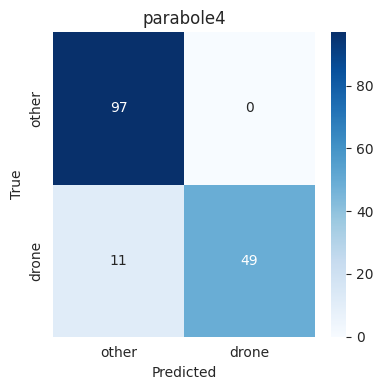

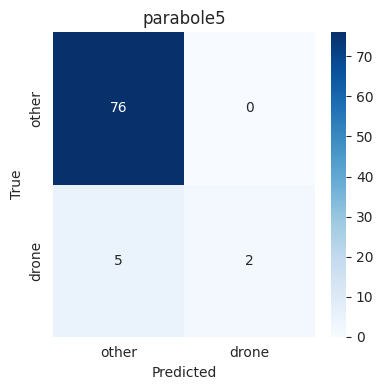

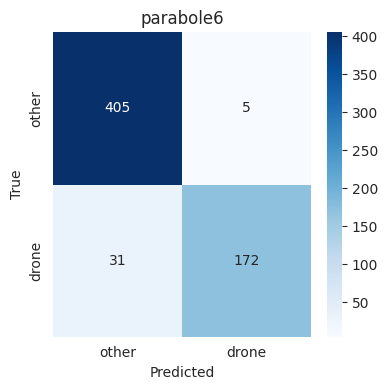

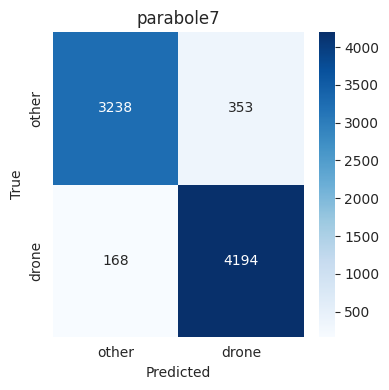

In [16]:
def plot_confusion(cm, title):
    plt.figure(figsize=(4,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.tight_layout()
    plt.show()

for split, metric in metrics.items():
    plot_confusion(metric["confusion_matrix"], split)


## Custom Inference on WAV files

In [ ]:
def infer_from_folder(folder_path: str):
    files = [f for f in os.listdir(folder_path) if f.endswith('.wav')]
    results = []
    acc = 0

    for file in files:
        file_path = os.path.join(folder_path, file)
        waveform, sr = librosa.load(file_path, sr=16000)
        mel_spec = convert_to_mel_spectrogram(waveform).unsqueeze(0)
        mel_spec = mel_spec.to(DEVICE)

        with torch.no_grad():
            logits = model(mel_spec)
            probs = torch.sigmoid(logits).squeeze(1)
            pred = (probs > 0.5).float().cpu().item()
            confidence = probs.cpu().item()

        acc += pred
        print(file, int(pred), confidence)
        results.append({
            "file": file,
            "predicted_label": int(pred),
            "confidence": confidence
        })

    print("Acc: ", acc / len(files))

print(f"0 is {"other"}, 1 is {"drone"}")
infer_from_folder("")

## Upload Models to HuggingFace Hub
We only save the model for inference in the Hibou Server Project. No versionning is done here.

In [18]:
from huggingface_hub import create_repo, upload_file

repo_id = "Hibou-Foundation/audio-models"
create_repo(repo_id, exist_ok=True)

upload_file(
    path_or_fileobj=MODEL_SAVE_PATH,
    path_in_repo="resnet_custom.pt",
    repo_id=repo_id,
)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

CommitInfo(commit_url='https://huggingface.co/Hibou-Foundation/audio-models/commit/5778b39fb5d565503ff3ca396b0756bad4d7e760', commit_message='Upload resnet_custom.pt with huggingface_hub', commit_description='', oid='5778b39fb5d565503ff3ca396b0756bad4d7e760', pr_url=None, repo_url=RepoUrl('https://huggingface.co/Hibou-Foundation/audio-models', endpoint='https://huggingface.co', repo_type='model', repo_id='Hibou-Foundation/audio-models'), pr_revision=None, pr_num=None)